## What are the most demanded skills for the top 3 most popular data roles? 
### Methodology
 1. Clean-up skill column
 2. Calculate skill count based on Job_title_short
 3. Calculate skill percentage 
 4. Plot final findings

In [15]:
## importing libraries 
import ast
import pandas as pd
import seaborn as sns 
from datasets import load_dataset
import matplotlib.pyplot as plt 

## loading data 
dataset= load_dataset('lukebarousse/data_jobs')
df= dataset['train'].to_pandas()

## data cleaning 
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [16]:
## data frames for united states only 
df_us = df[df['job_country']=='United States'].copy()
## exploding job skills
df_skills = df_us.explode('job_skills')


In [17]:
## counting skills by job title
df_skills_count= df_skills.groupby(['job_skills','job_title_short']).size()
## resetting index and sorting values
df_skills_count= df_skills_count.reset_index(name='Skill_count')
df_skills_count.sort_values(by='Skill_count', ascending=False, inplace=True)
## displaying data frame 
df_skills_count

,job_skills,job_title_short,Skill_count
1209,python,Data Scientist,42379
1521,sql,Data Analyst,34452
1523,sql,Data Scientist,30034
455,excel,Data Analyst,27519
1243,r,Data Scientist,26022
...,...,...,...
245,clojure,Software Engineer,1
1738,vb.net,Senior Data Scientist,1
530,fortran,Machine Learning Engineer,1
1116,planner,Cloud Engineer,1


In [18]:
job_titles = df_skills_count['job_title_short'].unique().tolist()
job_titles= sorted(job_titles[:3] ) # Limiting to first 3 job titles for brevity
job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

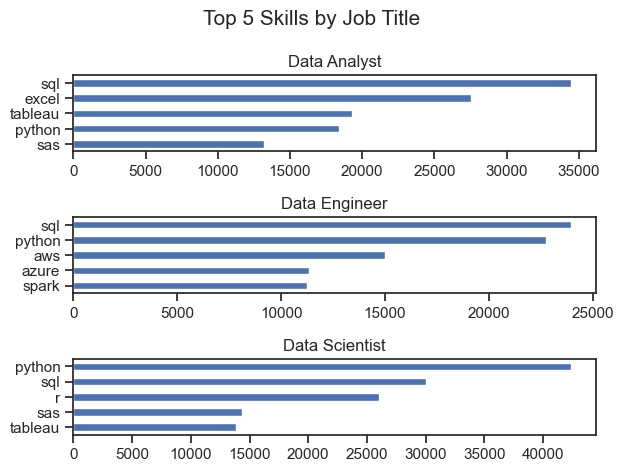

In [19]:
fig , ax = plt.subplots(len(job_titles),1)

for i, job_title in enumerate (job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short']== job_title].head(5)
    df_plot.plot(kind='barh', x='job_skills', y='Skill_count', ax=ax[i], title= job_title,legend=False)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')


fig.suptitle('Top 5 Skills by Job Title', fontsize=15)
plt.tight_layout()
plt.show()

In [20]:
df_job_title_count=df_us ['job_title_short'].value_counts().reset_index(name='jobs_total')

In [21]:
df_skill_perc=pd.merge(df_skills_count, df_job_title_count, how='left',on='job_title_short')

In [22]:
df_skill_perc['skill_percent']= (df_skill_perc['Skill_count']/ df_skill_perc['jobs_total'])*100

df_skill_perc

,job_skills,job_title_short,Skill_count,jobs_total,skill_percent
0,python,Data Scientist,42379,58830,72.036376
1,sql,Data Analyst,34452,67816,50.802171
2,sql,Data Scientist,30034,58830,51.052184
3,excel,Data Analyst,27519,67816,40.578919
4,r,Data Scientist,26022,58830,44.232534
...,...,...,...,...,...
1865,clojure,Software Engineer,1,1814,0.055127
1866,vb.net,Senior Data Scientist,1,12946,0.007724
1867,fortran,Machine Learning Engineer,1,921,0.108578
1868,planner,Cloud Engineer,1,423,0.236407


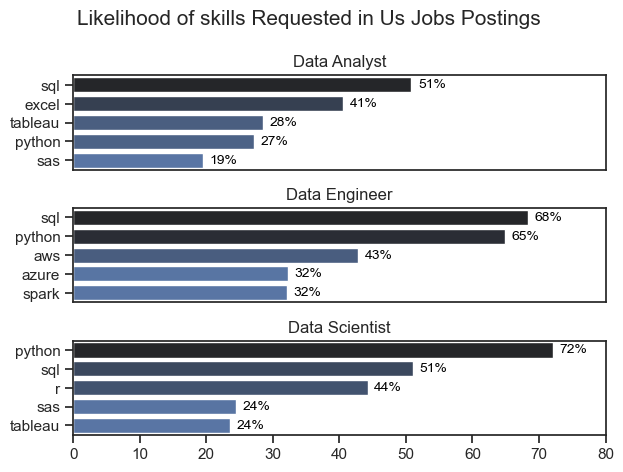

In [36]:
fig , ax = plt.subplots(len(job_titles),1)
sns.set_theme(style='ticks')
for i, job_title in enumerate (job_titles):
    df_plot = df_skill_perc[df_skill_perc['job_title_short']== job_title].head(5)
    # df_plot.plot(kind='barh', x='job_skills', y='skill_percent', ax=ax[i], title= job_title,legend=False)
    sns.barplot(data=df_plot, x='skill_percent', y='job_skills', ax=ax[i],hue='Skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].set_xlim(0,80)
    ax[i].legend().set_visible(False)
   
    for n ,v in enumerate (df_plot['skill_percent']):
        ax[i].text(v +1 , n , f"{v:.0f}%", color='black', va='center',fontsize=10)

    if i != len(job_titles) - 1:
        ax[i].set_xticks([])


fig.suptitle('Likelihood of skills Requested in Us Jobs Postings ', fontsize=15)
plt.tight_layout()
plt.show()